# [Human-in-the-Loop](https://docs.langchain.com/oss/python/deepagents/human-in-the-loop)

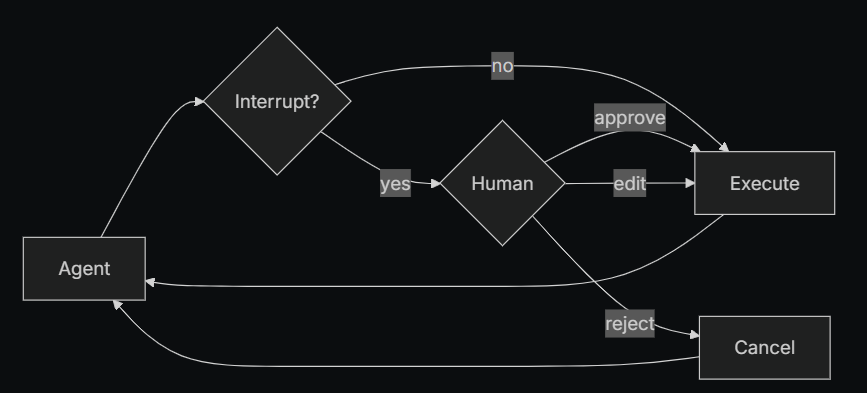

## 1. Human-in-the-Loop란?

Human-in-the-Loop(HITL)은 AI 에이전트가 **민감하거나 중요한 작업을 수행하기 전에 사람의 승인을 받도록** 하는 메커니즘입니다.


### 왜 필요한가?

- **안전성**: 파일 삭제, 데이터 변경 등 되돌릴 수 없는 작업
- **보안**: 이메일 전송, API 호출 등 외부 통신
- **비용**: 유료 API 호출, 리소스 집약적 작업
- **컴플라이언스**: 법적/규정상 인간의 검토가 필요한 작업

### 핵심 기능

1. **도구별 설정**: 각 도구마다 다른 승인 정책 적용 가능
2. **결정 유형**: 승인(approve), 편집(edit), 거부(reject)
3. **배치 처리**: 여러 도구 호출을 한 번에 검토
4. **Subagent 지원**: 하위 에이전트별로 독립적인 정책 설정


## 2. Setup


### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)

In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

True

### LLM 정의 

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


### 데이터 생성

data 폴더에 있는 sample용 csv와 json 파일을 이용해서 파일 생성 
-  `sample_samsung_stock.csv` -> `samsung_stock.csv`
-  `sample_sokcho_travel_guide.json` -> `sokcho_travel_guide.json`

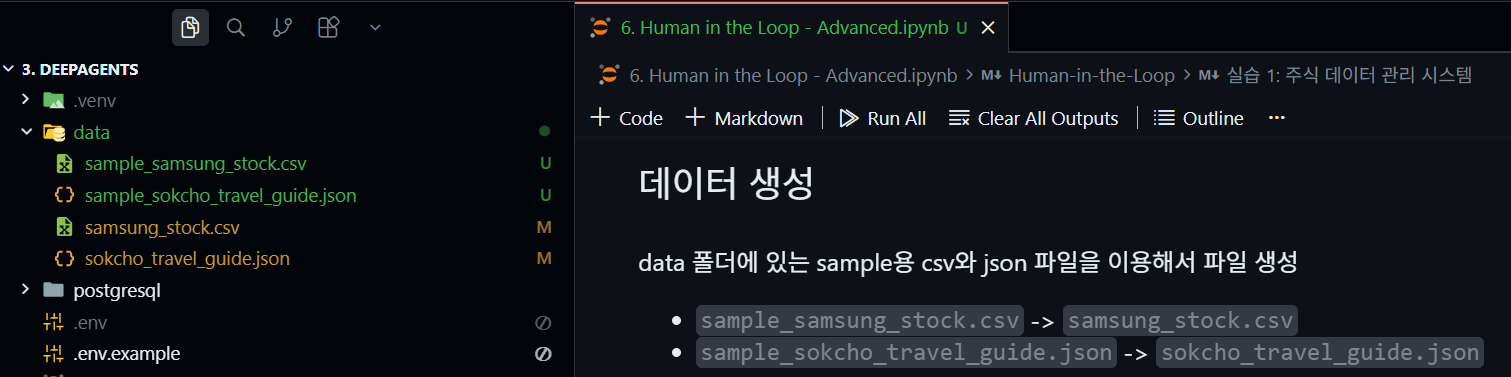

## 실습 1: 주식 데이터 관리 시스템

삼성전자 주식 데이터를 관리하는 시스템을 만들어봅시다. 데이터 삭제나 수정 같은 민감한 작업은 인간의 승인이 필요합니다.


### 데이터 확인

In [3]:
import pandas as pd

# 주식 데이터 로드
stock_df = pd.read_csv("data/samsung_stock.csv")

print(f"총 {len(stock_df)}일의 데이터")
print(stock_df.tail())


총 129일의 데이터
           Date   Open   High    Low  Close    Volume    Change
124  2025-07-09  61400  61400  60200  60400  17533415 -0.016287
125  2025-07-10  60600  61200  60400  61000  14768473  0.009934
126  2025-07-11  61300  62800  61200  62600  19140650  0.026230
127  2025-07-14  62300  62600  61800  62500  13563846 -0.001597
128  2025-07-15  62300  63800  62000  63700  17917574  0.019200


### 주식 관리 도구 정의


In [4]:
from langchain.tools import tool
from typing import Optional

@tool
def read_stock_data(start_date: Optional[str] = None, end_date: Optional[str] = None) -> str:
    """
    read_stock_data: 데이터 조회 (안전)
    삼성전자 주식 데이터를 조회합니다.
    
    Args:
        start_date: 시작 날짜 (YYYY-MM-DD 형식, 선택사항)
        end_date: 종료 날짜 (YYYY-MM-DD 형식, 선택사항)
    
    Returns:
        주식 데이터 정보
    """
    df = pd.read_csv("data/samsung_stock.csv")
    
    if start_date:
        df = df[df['Date'] >= start_date]
    if end_date:
        df = df[df['Date'] <= end_date]
    
    if len(df) == 0:
        return "해당 기간의 데이터가 없습니다."
    
    result = f"총 {len(df)}일의 데이터\n"
    result += f"기간: {df.iloc[0]['Date']} ~ {df.iloc[-1]['Date']}\n"
    result += f"최고가: {df['High'].max():,}원\n"
    result += f"최저가: {df['Low'].min():,}원\n"
    result += f"평균 종가: {df['Close'].mean():.2f}원\n"
    result += f"\n최근 5일 데이터:\n{df.tail().to_string()}"
    
    return result

In [5]:
@tool
def delete_stock_data(date: str) -> str:
    """
    delete_stock_data: 데이터 삭제 (위험)
    특정 날짜의 주식 데이터를 삭제합니다.
    
    Args:
        date: 삭제할 날짜 (YYYY-MM-DD 형식)
    
    Returns:
        삭제 결과 메시지
    """
    df = pd.read_csv("data/samsung_stock.csv")
    original_count = len(df)
    
    df = df[df['Date'] != date]
    new_count = len(df)
    
    if original_count == new_count:
        return f"❌ {date}에 해당하는 데이터가 없습니다."
    
    df.to_csv("data/samsung_stock.csv", index=False)
    return f"{date}의 데이터를 삭제했습니다. ({original_count} → {new_count}건)"


In [6]:
@tool
def update_stock_price(date: str, close_price: float) -> str:
    """
    update_stock_price: 가격 수정 (주의)
    특정 날짜의 종가를 수정합니다.
    
    Args:
        date: 수정할 날짜 (YYYY-MM-DD 형식)
        close_price: 새로운 종가
    
    Returns:
        수정 결과 메시지
    """
    df = pd.read_csv("data/samsung_stock.csv")
    
    if date not in df['Date'].values:
        return f"❌ {date}에 해당하는 데이터가 없습니다."
    
    old_price = df.loc[df['Date'] == date, 'Close'].values[0]
    df.loc[df['Date'] == date, 'Close'] = close_price
    
    df.to_csv("data/samsung_stock.csv", index=False)
    return f"{date}의 종가를 {old_price:,}원 → {close_price:,}원으로 수정했습니다."


In [7]:
@tool
def send_stock_report(recipient: str, date_range: str, summary: str) -> str:
    """
    send_stock_report: 리포트 전송 (검토 필요)
    주식 리포트를 이메일로 전송합니다.
    
    Args:
        recipient: 수신자 이메일
        date_range: 분석 기간
        summary: 리포트 요약
    
    Returns:
        전송 결과 메시지
    """
    # 실제로는 이메일을 전송하지만, 데모를 위해 로그만 출력
    return f"주식 리포트를 {recipient}에게 전송했습니다.\n기간: {date_range}\n요약: {summary}"


### HITL 없이 에이전트 생성 (위험!)

In [8]:
from deepagents import create_deep_agent

# HITL 없이 에이전트 생성 (위험!)
unsafe_agent = create_deep_agent(
    model=llm,
    tools=[read_stock_data, delete_stock_data, update_stock_price, send_stock_report],
    system_prompt="당신은 주식 데이터를 관리하는 전문 에이전트입니다."
)

print("HITL이 설정되지 않은 에이전트 생성됨")
print("에이전트가 사용자 승인 없이 데이터를 삭제하거나 수정할 수 있습니다!")


HITL이 설정되지 않은 에이전트 생성됨
에이전트가 사용자 승인 없이 데이터를 삭제하거나 수정할 수 있습니다!


### HITL이 있는 에이전트 (안전한 버전)


#### Redis 시작하기

터미널에서 다음 명령어를 실행하세요:

```bash
cd redis
docker-compose up -d
```

Redis가 정상적으로 실행되었는지 확인:

```bash
docker ps
```

In [9]:
from common.redis import get_redis_client

redis_client = get_redis_client()

RedisJSON 모듈 확인 완료!


#### RedisSaver

In [10]:
from langgraph.checkpoint.redis import RedisSaver

# Checkpointer 주입
checkpointer = RedisSaver(redis_client=redis_client)

# 처음 실행 시 인덱스가 생성될 때까지 아주 짧은 시간이 걸릴 수 있습니다.
try:
    # 내부적으로 인덱스를 생성하도록 유도
    checkpointer.setup() 
    print("체크포인트 인덱스 설정 완료")
except Exception as e:
    print(f"인덱스 설정 중 참고사항: {e}")


체크포인트 인덱스 설정 완료


#### safe_agent with HITL

In [11]:
# HITL 설정과 함께 에이전트 생성
safe_agent = create_deep_agent(
    model=llm,
    tools=[read_stock_data, delete_stock_data, update_stock_price, send_stock_report],
    system_prompt="당신은 주식 데이터를 관리하는 전문 에이전트입니다.",
    interrupt_on={
        "read_stock_data": False,  # 읽기는 안전하므로 승인 불필요
        "delete_stock_data": True,  # 삭제는 위험! 기본 옵션(approve, edit, reject)
        "update_stock_price": {
            "allowed_decisions": ["approve", "edit", "reject"]},  # 수정도 전체 옵션
        "send_stock_report": {
            "allowed_decisions": ["approve", "reject"]},  # 전송은 승인/거부만
    },
    checkpointer=checkpointer  # 필수!
)

print("HITL이 설정된 안전한 에이전트 생성 완료")
print("\n승인 정책:")
print("  - read_stock_data: 승인 불필요 (안전한 읽기 작업)")
print("  - delete_stock_data: 승인 필요 (approve/edit/reject 가능)")
print("  - update_stock_price: 승인 필요 (approve/edit/reject 가능)")
print("  - send_stock_report: 승인 필요 (approve/reject만 가능, edit 불가)")


HITL이 설정된 안전한 에이전트 생성 완료

승인 정책:
  - read_stock_data: 승인 불필요 (안전한 읽기 작업)
  - delete_stock_data: 승인 필요 (approve/edit/reject 가능)
  - update_stock_price: 승인 필요 (approve/edit/reject 가능)
  - send_stock_report: 승인 필요 (approve/reject만 가능, edit 불가)


### 데이터 삭제 요청 (Approve)

이 시나리오에서는 데이터 삭제 요청이 인터럽트되고, 사용자가 승인하는 과정을 단계별로 살펴봅니다.


#### Step 1: 주식 데이터 확인

In [12]:
import pandas as pd

# 주식 데이터 로드
stock_df = pd.read_csv("data/samsung_stock.csv")

> 2025-01-02 날짜의 주식 데이터 확인 

In [13]:
stock_df[stock_df['Date'] == "2025-01-02"]

,Date,Open,High,Low,Close,Volume,Change
0,2025-01-02,52700,53600,52300,53400,16630538,0.003759


#### Step 2: 테스트 실행

In [14]:
import uuid

# 새로운 스레드 생성 (이후 단계에서 같은 config 사용)
config_scenario1 = {"configurable": {"thread_id": str(uuid.uuid4())}}

# 에이전트에게 데이터 삭제 요청
result_scenario1 = safe_agent.invoke(
    {"messages": [{"role": "user", "content": "2025-01-02 날짜의 주식 데이터를 삭제해줘"}]},
    config=config_scenario1
)

print("에이전트 실행 완료. 다음 셀에서 인터럽트 상태를 확인하세요.")


에이전트 실행 완료. 다음 셀에서 인터럽트 상태를 확인하세요.


#### Step 3: 인터럽트 발생 확인 및 작업 상태 확인


In [15]:
import json

if result_scenario1.get("__interrupt__"):
    print("인터럽트가 발생했습니다!\n")
    
    interrupts = result_scenario1["__interrupt__"][0].value
    action_requests = interrupts["action_requests"]
    review_configs = interrupts["review_configs"]
    
    print("=" * 60)
    print("대기 중인 작업 상세 정보")
    print("=" * 60)
    
    # 각 작업의 상세 정보 표시
    for i, action in enumerate(action_requests):
        config_for_action = review_configs[i]
        print(f"\n작업 #{i+1}")
        print(f"-  도구명: {action['name']}")
        print(f"-  인자: {json.dumps(action['args'], ensure_ascii=False)}")
        print(f"-  허용된 결정: {config_for_action['allowed_decisions']}")
    
    print("\n" + "=" * 60)
    print("다음 셀에서 사용자 결정을 내리세요.")
    print("=" * 60)
else:
    print("인터럽트가 발생하지 않았습니다.")


인터럽트가 발생했습니다!

대기 중인 작업 상세 정보

작업 #1
-  도구명: delete_stock_data
-  인자: {"date": "2025-01-02"}
-  허용된 결정: ['approve', 'edit', 'reject']

다음 셀에서 사용자 결정을 내리세요.


#### Step 4: 사용자 결정: 승인 (approve)


In [16]:
# 사용자 결정: 승인 (approve)
# 옵션: "approve", "edit", "reject"

# 결정 생성
decisions_scenario1 = [{"type": "approve"}]

print("결정 완료: 승인 (approve)")
print("다음 셀에서 결정을 적용하고 작업을 진행합니다.")


결정 완료: 승인 (approve)
다음 셀에서 결정을 적용하고 작업을 진행합니다.


#### Step 5: 결정 적용 및 결과 확인


In [17]:
from langgraph.types import Command

# 결정을 적용하고 에이전트 재개
result_scenario1_final = safe_agent.invoke(
    Command(resume={"decisions": decisions_scenario1}),
    config=config_scenario1
)

print("=" * 60)
print("작업 완료!")
print("=" * 60)
print(f"\n최종 결과:\n{result_scenario1_final['messages'][-1].content}")


작업 완료!

최종 결과:
완료했습니다. 2025-01-02 날짜의 주식 데이터가 삭제되었습니다.
- 상태: 삭제 성공 (129건 → 128건)
- 남은 데이터 건수: 128건

다음에 하실 작업이 있나요? 예를 들어 다른 날짜 삭제, 특정 기간 조회, 백업, 리포트 작성 등 도와드리겠습니다. 원하는 작업을 알려주시면 바로 진행할게요.


> 삭제 결과 확인 

In [18]:
import pandas as pd

# 주식 데이터 로드
stock_df = pd.read_csv("data/samsung_stock.csv")

print("파일로 부터 해당 데이터 삭제 유무 확인")
stock_df[stock_df['Date'] == "2025-01-02"]

파일로 부터 해당 데이터 삭제 유무 확인


,Date,Open,High,Low,Close,Volume,Change


### 가격 수정 요청 (Edit)

#### Step 1: 종가 데이터 확인 

In [19]:
import pandas as pd

# 주식 데이터 로드
stock_df = pd.read_csv("data/samsung_stock.csv")

print(f"2025-01-03 날짜의 종가: {stock_df[stock_df['Date'] == "2025-01-03"]['Close'].values[0]}")
stock_df[stock_df['Date'] == "2025-01-03"]

2025-01-03 날짜의 종가: 54400


,Date,Open,High,Low,Close,Volume,Change
0,2025-01-03,52800,55100,52800,54400,19318046,0.018727


#### Step 2: 테스트 실행 

In [20]:
# 새로운 스레드 생성
config_scenario2 = {"configurable": {"thread_id": str(uuid.uuid4())}}

# 가격 수정 요청
result_scenario2 = safe_agent.invoke(
    {"messages": [{"role": "user", "content": "2025-01-03 날짜의 종가를 77000원으로 수정해줘"}]},
    config=config_scenario2
)

print("에이전트 실행 완료. 다음 셀에서 인터럽트 상태를 확인하세요.")


에이전트 실행 완료. 다음 셀에서 인터럽트 상태를 확인하세요.


#### Step 3: 인터럽트 발생 확인

In [21]:
if result_scenario2.get("__interrupt__"):
    print("인터럽트가 발생했습니다!\n")

    interrupts = result_scenario2["__interrupt__"][0].value
    action_request_s2 = interrupts["action_requests"][0]
    review_config_s2 = interrupts["review_configs"][0]
    
    print("=" * 60)
    print("대기 중인 작업 상세 정보")
    print("=" * 60)
    print(f"\n도구명: {action_request_s2['name']}")
    print(f"원래 요청 인자:")
    print(f"   - 날짜: {action_request_s2['args']['date']}")
    print(f"   - 종가: {action_request_s2['args']['close_price']:,}원")
    print(f"   - 허용된 결정: {review_config_s2['allowed_decisions']}")
    
    print("\n" + "=" * 60)
    print("다음 셀에서 사용자 결정을 내리세요.")
    print("이 시나리오에서는 'edit'을 사용하여 가격을 수정합니다.")
    print("=" * 60)
else:
    print("인터럽트가 발생하지 않았습니다.")


인터럽트가 발생했습니다!

대기 중인 작업 상세 정보

도구명: update_stock_price
원래 요청 인자:
   - 날짜: 2025-01-03
   - 종가: 77,000원
   - 허용된 결정: ['approve', 'edit', 'reject']

다음 셀에서 사용자 결정을 내리세요.
이 시나리오에서는 'edit'을 사용하여 가격을 수정합니다.


#### Step 4: 사용자 결정: 가격을 수정 (edit)


In [22]:
# 사용자 결정: 가격을 수정 (edit)

# 원래 요청에서 정보 가져오기
interrupts = result_scenario2["__interrupt__"][0].value
action_request_s2 = interrupts["action_requests"][0]

print(f"원래 요청: 종가 {action_request_s2['args']['close_price']:,}원")

edit_close_price = 80000 # 수정된 가격
print(f"수정 결정: 종가 {edit_close_price:,}원으로 변경\n")

# Edit 결정 생성
decisions_scenario2 = [{
    "type": "edit",
    "edited_action": {
        "name": action_request_s2["name"],
        "args": {
            "date": action_request_s2['args']['date'],
            "close_price": edit_close_price  # 수정된 가격
        }
    }
}]

print("결정 완료: 수정 (edit)")
print("다음 셀에서 수정된 값으로 작업을 진행합니다.")


원래 요청: 종가 77,000원
수정 결정: 종가 80,000원으로 변경

결정 완료: 수정 (edit)
다음 셀에서 수정된 값으로 작업을 진행합니다.


#### Step 5: 결정 적용 및 결과 확인


In [23]:
# 수정된 결정을 적용하고 에이전트 재개
result_scenario2_final = safe_agent.invoke(
    Command(resume={"decisions": decisions_scenario2}),
    config=config_scenario2
)

print("=" * 60)
print("작업 완료!")
print("=" * 60)
print(f"\n최종 결과:\n{result_scenario2_final['messages'][-1].content}")


작업 완료!

최종 결과:



> 수정된 내용 확인 

In [24]:
import pandas as pd

# 주식 데이터 로드
stock_df = pd.read_csv("data/samsung_stock.csv")

print(f"2025-01-03 날짜의 종가: {stock_df[stock_df['Date'] == "2025-01-03"]['Close'].values[0]}")
stock_df[stock_df['Date'] == "2025-01-03"]

2025-01-03 날짜의 종가: 80000


,Date,Open,High,Low,Close,Volume,Change
0,2025-01-03,52800,55100,52800,80000,19318046,0.018727


## 실습 2: 여행 가이드 관리 시스템

속초 여행 가이드 정보를 관리하는 시스템을 만들어봅시다.


### 데이터 확인

In [25]:
import json

# 여행 가이드 데이터 로드
with open("data/sokcho_travel_guide.json", "r", encoding="utf-8") as f:
    travel_data = json.load(f)

print("속초 여행 가이드 정보\n")
print(json.dumps(travel_data, ensure_ascii=False, indent=2))


속초 여행 가이드 정보

{
  "location": "강원특별자치도 속초시",
  "date": "2025-07-15",
  "weather": {
    "temperature": "25°C",
    "condition": "맑음",
    "humidity": "60%"
  },
  "tourist_attractions": [
    {
      "name": "속초해수욕장",
      "description": "아름다운 해변과 시원한 바닷바람이 매력적인 명소",
      "tip": "여름철 피서지로 인기 많음"
    },
    {
      "name": "설악산 국립공원",
      "description": "울산바위, 권금성 등 다양한 명소가 있는 국립공원",
      "tip": "트레킹과 자연 풍경 감상에 최적"
    },
    {
      "name": "아바이마을",
      "description": "6.25 전쟁 당시 피난민이 정착한 전통 마을",
      "tip": "갯배 체험과 향토 음식 즐기기 가능"
    }
  ],
  "local_cuisine": [
    {
      "dish": "닭강정",
      "description": "속초의 명물! 달콤하고 바삭한 맛이 특징"
    },
    {
      "dish": "오징어순대",
      "description": "오징어 안에 찹쌀과 채소를 넣어 찐 전통 음식"
    }
  ],
  "travel_tips": [
    "해수욕장과 산을 함께 즐길 수 있는 복합형 여행지",
    "중앙시장 등지에서 지역 음식을 현지 스타일로 맛볼 수 있음",
    "아바이마을 갯배 체험은 필수 코스"
  ]
}


### 여행 가이드 관리 도구 정의


In [26]:
from langchain.tools import tool

@tool
def read_travel_guide() -> str:
    """속초 여행 가이드 정보를 조회합니다."""
    with open("data/sokcho_travel_guide.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    return json.dumps(data, ensure_ascii=False, indent=2)


@tool
def add_attraction(name: str, description: str, tip: str) -> str:
    """새로운 관광 명소를 추가합니다.
    
    Args:
        name: 명소 이름
        description: 설명
        tip: 여행 팁
    """
    with open("data/sokcho_travel_guide.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    
    new_attraction = {
        "name": name,
        "description": description,
        "tip": tip
    }
    
    data["tourist_attractions"].append(new_attraction)
    
    with open("data/sokcho_travel_guide.json", "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    
    return f"'{name}' 명소를 추가했습니다."


@tool
def delete_attraction(name: str) -> str:
    """관광 명소를 삭제합니다. ⚠️ 위험한 작업!
    
    Args:
        name: 삭제할 명소 이름
    """
    with open("data/sokcho_travel_guide.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    
    original_count = len(data["tourist_attractions"])
    data["tourist_attractions"] = [
        a for a in data["tourist_attractions"] if a["name"] != name
    ]
    new_count = len(data["tourist_attractions"])
    
    if original_count == new_count:
        return f"'{name}' 명소를 찾을 수 없습니다."
    
    with open("data/sokcho_travel_guide.json", "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    
    return f"'{name}' 명소를 삭제했습니다."


@tool
def send_travel_guide(recipient: str, attractions: str) -> str:
    """여행 가이드를 이메일로 전송합니다.
    
    Args:
        recipient: 수신자 이메일
        attractions: 추천 명소 목록
    """
    return f"여행 가이드를 {recipient}에게 전송했습니다.\n추천 명소: {attractions}"


### HITL 에이전트 생성

#### PostgreSQL 시작하기

터미널에서 다음 명령어를 실행하세요:

```bash
cd postgresql
docker-compose up -d
```

정상적으로 실행되었는지 확인:

```bash
docker ps
```

In [27]:
# PostgreSQL 연결 설정
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "deepagent_db",
    "user": "admin",
    "password": "admin123"  # 실제 운영에서는 환경변수로 관리!
}


In [28]:
from common.postgresql import PostgreDB

# 싱글톤 패턴 동작 확인
print("\n=== 싱글톤 패턴 동작 확인 ===")
conn1 = PostgreDB(DB_CONFIG).get_conn()
conn2 = PostgreDB(DB_CONFIG).get_conn()

print(f"\n첫 번째 연결: {conn1}")
print(f"두 번째 연결: {conn2}")
print(f"같은 연결인가? {conn1 is conn2}")  # True여야 함
print("\n✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.")


=== 싱글톤 패턴 동작 확인 ===

첫 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=deepagent_db) at 0x1173127b0>
두 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=deepagent_db) at 0x1173127b0>
같은 연결인가? True

✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.


#### PostgresSaver

In [29]:
from langgraph.checkpoint.postgres import PostgresSaver

# PostgresSaver 생성자에 직접 연결과 serde 전달
travel_checkpointer = PostgresSaver(PostgreDB(DB_CONFIG).get_conn()) 
travel_checkpointer.setup()  # 필요한 테이블 자동 생성

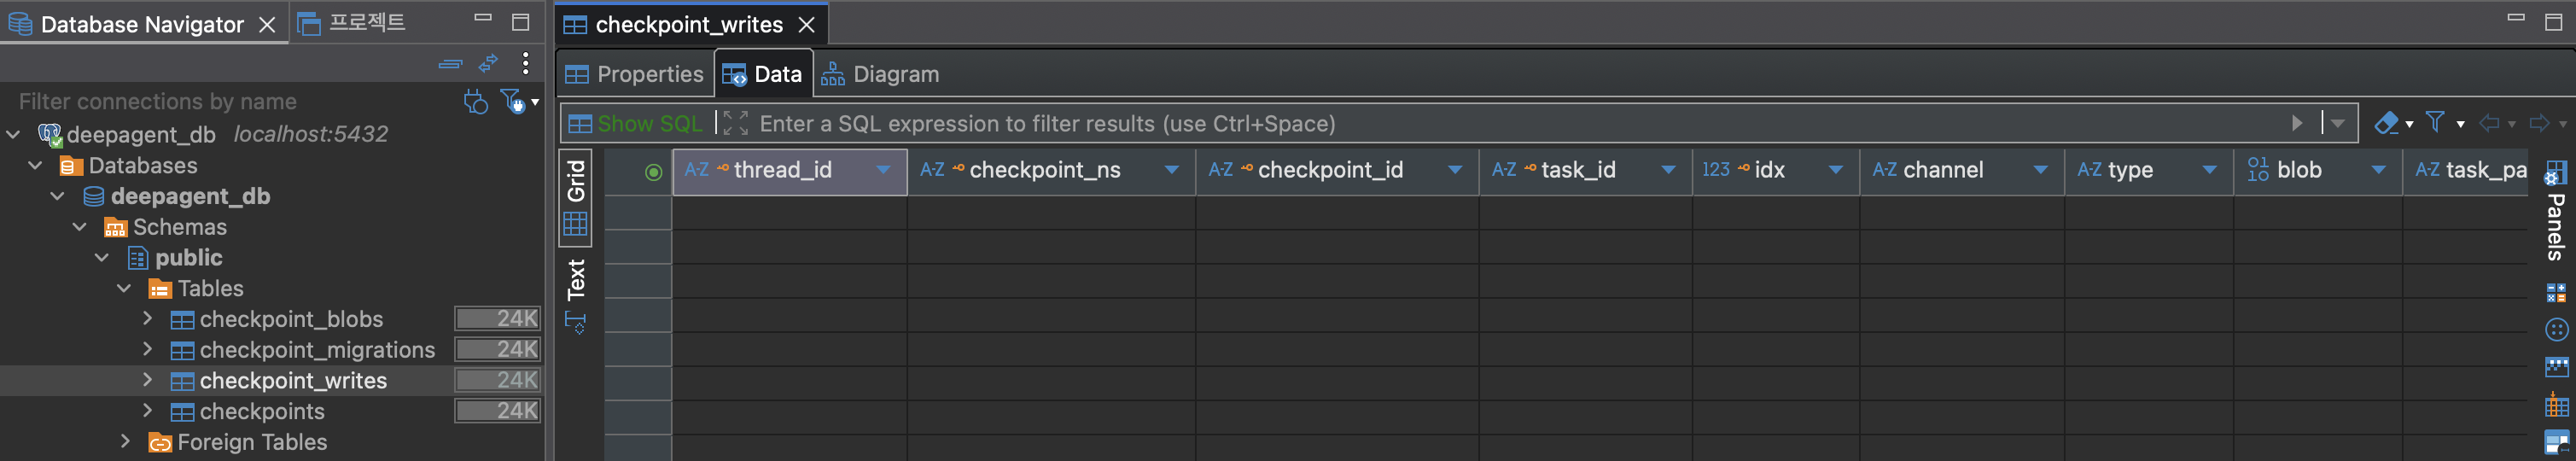

#### travel_agent with HITL

In [30]:
from deepagents import create_deep_agent

# HITL 설정 (병렬 도구 호출을 위한 시스템 프롬프트)
travel_agent = create_deep_agent(
    model=llm,
    tools=[read_travel_guide, add_attraction, delete_attraction, send_travel_guide],
    system_prompt="""당신은 속초 여행 가이드를 관리하는 에이전트입니다.

중요: 사용자가 여러 작업을 요청하면, 가능한 한 모든 도구를 동시에(parallel) 호출하세요.
예: 명소 추가와 이메일 전송을 함께 요청받으면, 두 도구를 한 번에 호출하세요.""",
    interrupt_on={
        "read_travel_guide": False,
        "add_attraction": True,
        "delete_attraction": True,
        "send_travel_guide": {
            "allowed_decisions": ["approve", "reject"]},
    },
    checkpointer=travel_checkpointer
)

print("여행 가이드 에이전트 생성 완료 (병렬 도구 호출 지원)\n")


여행 가이드 에이전트 생성 완료 (병렬 도구 호출 지원)



### 테스트 

#### Step 1: 여러 작업을 동시에 요청

**목표**: 에이전트가 2개의 도구를 **병렬로(parallel)** 호출하도록 유도하여, 2개의 작업이 동시에 인터럽트되는 상황을 만듭니다.

**핵심**:
- 시스템 프롬프트에 병렬 호출 지시 포함
- 사용자 메시지에 "동시에", "한 번에" 같은 키워드 사용
- 각 도구와 파라미터를 명확히 지정

In [31]:
import uuid

# 여러 작업을 동시에 요청 (병렬 도구 호출 유도)
config_travel = {"configurable": {"thread_id": str(uuid.uuid4())}}

result_travel = travel_agent.invoke(
    {
        "messages": [{
            "role": "user",
            "content": """
다음 2가지 작업을 동시에 수행해주세요:

1. '영랑호'라는 명소를 추가 (add_attraction 도구 사용)
   - name: "영랑호"
   - description: "속초의 아름다운 호수"
   - tip: "산책로를 따라 걷기 좋음"
2. '[email protected]'에게 여행 가이드 전송 (send_travel_guide 도구 사용)
   - recipient: "[email protected]"
   - attractions: "속초 주요 관광지"

두 도구를 한 번에 호출하세요."""
        }]
    },
    config=config_travel
)

print("에이전트 실행 완료. 다음 셀에서 인터럽트 상태를 확인하세요.")

에이전트 실행 완료. 다음 셀에서 인터럽트 상태를 확인하세요.


#### Step 2: 인터럽트 발생 확인 및 작업 상태 확인 (배치 처리)


In [32]:
# Step 2: 인터럽트 발생 확인
if result_travel.get("__interrupt__"):
    print("여러 작업이 인터럽트되었습니다!\n")
    
    interrupts_travel = result_travel["__interrupt__"][0].value
    action_requests_travel = interrupts_travel["action_requests"]
    review_configs_travel = interrupts_travel["review_configs"]
    
    print("=" * 60)
    print(f"총 {len(action_requests_travel)}개의 작업이 대기 중")
    print("=" * 60)
    
    # 각 작업의 상세 정보 표시
    for i, (action, review_config) in enumerate(
            zip(action_requests_travel, review_configs_travel)):
        print(f"\n{'─'*60}")
        print(f"작업 #{i+1}")
        print(f"{'─'*60}")
        print(f"  - 도구명: {action['name']}")
        print(f"  - 인자: {json.dumps(action['args'], ensure_ascii=False, indent=2)}")
        print(f"  - 허용된 결정: {review_config['allowed_decisions']}")
    
    print("\n" + "=" * 60)
    print("다음 셀에서 각 작업에 대한 결정을 내리세요.")
    print("결정 순서는 작업 순서와 일치해야 합니다!")
    print("=" * 60)
else:
    print("인터럽트가 발생하지 않았습니다.")


여러 작업이 인터럽트되었습니다!

총 2개의 작업이 대기 중

────────────────────────────────────────────────────────────
작업 #1
────────────────────────────────────────────────────────────
  - 도구명: add_attraction
  - 인자: {
  "name": "영랑호",
  "description": "속초의 아름다운 호수",
  "tip": "산책로를 따라 걷기 좋음"
}
  - 허용된 결정: ['approve', 'edit', 'reject']

────────────────────────────────────────────────────────────
작업 #2
────────────────────────────────────────────────────────────
  - 도구명: send_travel_guide
  - 인자: {
  "recipient": "[email protected]",
  "attractions": "속초 주요 관광지"
}
  - 허용된 결정: ['approve', 'reject']

다음 셀에서 각 작업에 대한 결정을 내리세요.
결정 순서는 작업 순서와 일치해야 합니다!


#### Step 3: 사용자 결정 (각 작업별)


In [33]:
# 사용자 결정: 실제 인터럽트된 작업 수에 맞게 동적 결정
decisions_travel = [
    {"type": "approve"},    # add_attraction -> 승인 (approve)
    {"type": "reject"}      # send_travel_guide -> 거부 (reject) - 이메일 주소 확인 필요
]

print(f"총 {len(decisions_travel)}개의 결정 생성 완료")


총 2개의 결정 생성 완료


#### Step 4: 결정 적용 및 결과 확인


In [34]:
from langgraph.types import Command

# 모든 결정을 적용하고 에이전트 재개
result_travel_final = travel_agent.invoke(
    Command(resume={"decisions": decisions_travel}),
    config=config_travel
)

print("=" * 60)
print("모든 작업 처리 완료!")
print("=" * 60)
print(f"\n최종 결과:\n{result_travel_final['messages'][-1].content}")

print("\n" + "=" * 60)
print("요약:")
print("  - 작업 #1: 명소 추가가 승인되어 실행됨")
print("  - 작업 #2: 이메일 전송이 거부되어 실행되지 않음")
print("=" * 60)


모든 작업 처리 완료!

최종 결과:
두 작업을 동시에 시도했습니다. 결과는 아래와 같습니다.

- 명소 추가 완료: 영랑호가 추가되었습니다.
  - 이름: 영랑호
  - 설명: 속초의 아름다운 호수
  - 팁: 산책로를 따라 걷기 좋음

- 여행 가이드 전송 시도: [email protected]에게 "속초 주요 관광지" 안내를 보내려 했으나, 사용자가 전송 요청을 취소하여 실패했습니다.

다시 시도하시려면 알려 주세요.
- 재전송할지 여부
- 새로운 수신자 이메일 주소가 있다면 공유
- 혹은 전달 내용을 더 구체적으로 구성하고 싶은지(예: 구체적인 명소 목록 포함)

원하시는 방향으로 바로 진행해 드리겠습니다.

요약:
  - 작업 #1: 명소 추가가 승인되어 실행됨
  - 작업 #2: 이메일 전송이 거부되어 실행되지 않음


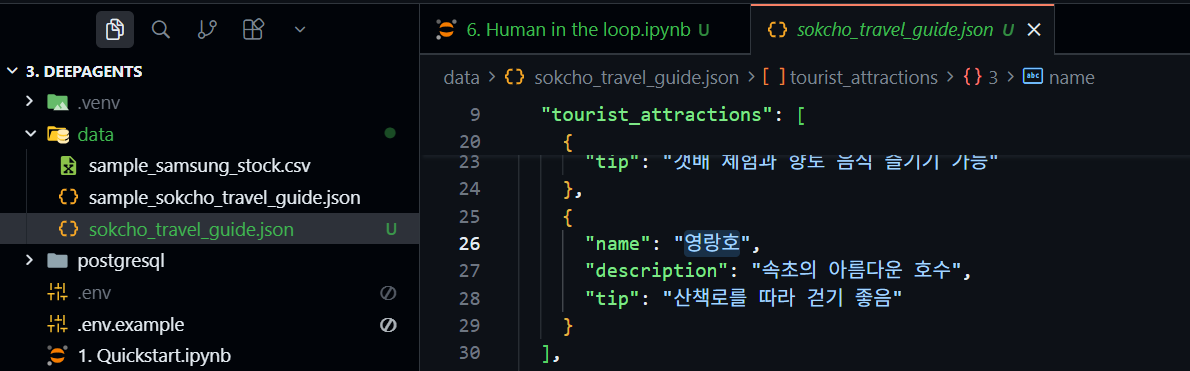